In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import plotly.express as px

#### Merge all LPI Excel files into one File

In [2]:
files=['Data export (2).xlsx',
    "Data export (3).xlsx",
    "Data export (4).xlsx",
    "Data export (5).xlsx",
    "Data export (6).xlsx",
    "Data export (7).xlsx",
    "Data export (8).xlsx"]
lpi_datasets=[]
for file in files:
    temp=pd.read_excel(file,header=None)
    temp.columns=temp.iloc[1]
    temp=temp.drop(index=[0,1]).reset_index(drop=True)
    lpi_datasets.append(temp)
lpi_merged_all=pd.concat(lpi_datasets,ignore_index=True)
lpi_merged_all.to_csv("Data exportm.csv")
lpi_merged_all

1,Country,Year,LPI Rank,LPI Score,Customs Rank,Customs Score,Infrastructure Rank,Infrastructure Score,International shipments Rank,International shipments Score,Logistics competence Rank,Logistics competence Score,Tracking & tracing Rank,Tracking & tracing Score,Timeliness Rank,Timeliness Score
0,Afghanistan,2007,150,1.21,150,1.3,150,1.1,150,1.22,150,1.25,150,1,150,1.38
1,Albania,2007,139,2.08,132,2,78,2.33,109,2.33,130,2,145,1.67,144,2.12
2,Algeria,2007,140,2.06,148,1.6,139,1.83,139,2,139,1.92,108,2.27,103,2.82
3,Angola,2007,86,2.48,71,2.4,88,2.25,87,2.5,81,2.5,94,2.38,100,2.83
4,Argentina,2007,45,2.98,51,2.65,47,2.81,49,2.97,44,3,46,3,46,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,Uzbekistan,2023,88,2.6,74,2.6,89,2.4,91,2.6,92,2.6,105,2.4,101,2.8
1075,"Venezuela, RB",2023,123,2.3,120,2.1,89,2.4,135,2,103,2.5,117,2.3,124,2.5
1076,Vietnam,2023,43,3.3,43,3.1,47,3.2,38,3.3,53,3.2,41,3.4,59,3.3
1077,"Yemen, Rep.",2023,132,2.2,137,1.7,132,1.9,139,1.7,92,2.6,117,2.3,101,2.8


#### loads DataCo and keeps only columns useful for delivery delay prediction

In [3]:
df=pd.read_csv('DataCoSupplyChainDataset.csv',encoding='latin1')
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [4]:
keep_cols = [
    "Delivery Status","Late_delivery_risk",
    "Days for shipping (real)", "Days for shipment (scheduled)",
    "Shipping Mode", "Order Status",
    "order date (DateOrders)", "shipping date (DateOrders)",
    "Market", "Order Region", "Order Country", "Order State", "Order City",
    "Customer Country", "Customer State", "Customer City",
    "Latitude", "Longitude",
    "Type", "Category Name","Department Name",
    "Product Name", "Product Price", 
    "Order Item Quantity", "Order Item Product Price",
    "Order Item Discount","Order Item Total", 
    "Sales", "Sales per customer",
    "Benefit per order", "Order Profit Per Order","Customer Segment"]
keep_cols=[c for c in keep_cols if c in df.columns]
df=df[keep_cols].copy().drop_duplicates()
df

,Delivery Status,Late_delivery_risk,Days for shipping (real),Days for shipment (scheduled),Shipping Mode,Order Status,order date (DateOrders),shipping date (DateOrders),Market,Order Region,...,Product Price,Order Item Quantity,Order Item Product Price,Order Item Discount,Order Item Total,Sales,Sales per customer,Benefit per order,Order Profit Per Order,Customer Segment
0,Advance shipping,0,3,4,Standard Class,COMPLETE,1/31/2018 22:56,2/3/2018 22:56,Pacific Asia,Southeast Asia,...,327.750000,1,327.750000,13.110000,314.640015,327.750000,314.640015,91.250000,91.250000,Consumer
1,Late delivery,1,5,4,Standard Class,PENDING,1/13/2018 12:27,1/18/2018 12:27,Pacific Asia,South Asia,...,327.750000,1,327.750000,16.389999,311.359985,327.750000,311.359985,-249.089996,-249.089996,Consumer
2,Shipping on time,0,4,4,Standard Class,CLOSED,1/13/2018 12:06,1/17/2018 12:06,Pacific Asia,South Asia,...,327.750000,1,327.750000,18.030001,309.720001,327.750000,309.720001,-247.779999,-247.779999,Consumer
3,Advance shipping,0,3,4,Standard Class,COMPLETE,1/13/2018 11:45,1/16/2018 11:45,Pacific Asia,Oceania,...,327.750000,1,327.750000,22.940001,304.809998,327.750000,304.809998,22.860001,22.860001,Home Office
4,Advance shipping,0,2,4,Standard Class,PENDING_PAYMENT,1/13/2018 11:24,1/15/2018 11:24,Pacific Asia,Oceania,...,327.750000,1,327.750000,29.500000,298.250000,327.750000,298.250000,134.210007,134.210007,Corporate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Shipping on time,0,4,4,Standard Class,CLOSED,1/16/2016 3:40,1/20/2016 3:40,Pacific Asia,Eastern Asia,...,399.980011,1,399.980011,0.000000,399.980011,399.980011,399.980011,40.000000,40.000000,Home Office
180515,Late delivery,1,3,2,Second Class,COMPLETE,1/16/2016 1:34,1/19/2016 1:34,Pacific Asia,Eastern Asia,...,399.980011,1,399.980011,4.000000,395.980011,399.980011,395.980011,-613.770019,-613.770019,Corporate
180516,Late delivery,1,5,4,Standard Class,PENDING,1/15/2016 21:00,1/20/2016 21:00,Pacific Asia,Oceania,...,399.980011,1,399.980011,8.000000,391.980011,399.980011,391.980011,141.110001,141.110001,Corporate
180517,Advance shipping,0,3,4,Standard Class,PENDING_PAYMENT,1/15/2016 20:18,1/18/2016 20:18,Pacific Asia,Oceania,...,399.980011,1,399.980011,12.000000,387.980011,399.980011,387.980011,186.229996,186.229996,Consumer


In [5]:
for c in ["order date (DateOrders)", "shipping date (DateOrders)"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

In [6]:
if "Days for shipping (real)" in df.columns and "Days for shipment (scheduled)" in df.columns:
    df["delivery_delay_days"] = (df["Days for shipping (real)"] - 
                                 df["Days for shipment (scheduled)"])

In [7]:
df.to_csv("DataCo_clean.csv", index=False)
df.shape

(180519, 33)

#### Merge LPI into DataCo using Country + Year

In [8]:
df = pd.read_csv("DataCo_clean.csv")
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")
df["Order Year"] = df["order date (DateOrders)"].dt.year
df["Order Country"] = df["Order Country"].str.strip()

In [9]:
lpi = pd.read_csv("Data exportm.csv")
lpi_keep = [
    "Country", "Year",
    "LPI Score",
    "Customs Score",
    "Infrastructure Score",
    "International shipments Score",
    "Logistics competence Score",
    "Tracking & tracing Score",
    "Timeliness Score"]
lpi= lpi[lpi_keep].copy()
lpi['Country']=lpi['Country'].str.strip()
lpi['Year']=pd.to_numeric(lpi['Year'],errors='coerce')
lpi=lpi.rename(columns={"Country": "Order Country", "Year": "Order Year"})
lpi

,Order Country,Order Year,LPI Score,Customs Score,Infrastructure Score,International shipments Score,Logistics competence Score,Tracking & tracing Score,Timeliness Score
0,Afghanistan,2007,1.21,1.30,1.10,1.22,1.25,1.00,1.38
1,Albania,2007,2.08,2.00,2.33,2.33,2.00,1.67,2.12
2,Algeria,2007,2.06,1.60,1.83,2.00,1.92,2.27,2.82
3,Angola,2007,2.48,2.40,2.25,2.50,2.50,2.38,2.83
4,Argentina,2007,2.98,2.65,2.81,2.97,3.00,3.00,3.50
...,...,...,...,...,...,...,...,...,...
1074,Uzbekistan,2023,2.60,2.60,2.40,2.60,2.60,2.40,2.80
1075,"Venezuela, RB",2023,2.30,2.10,2.40,2.00,2.50,2.30,2.50
1076,Vietnam,2023,3.30,3.10,3.20,3.30,3.20,3.40,3.30
1077,"Yemen, Rep.",2023,2.20,1.70,1.90,1.70,2.60,2.30,2.80


In [10]:
df_merged=df.merge(lpi,how="left",on=["Order Country", "Order Year"])
lpi_score_cols = [
    "LPI Score",
    "Customs Score",
    "Infrastructure Score",
    "International shipments Score",
    "Logistics competence Score",
    "Tracking & tracing Score",
    "Timeliness Score"]
for c in lpi_score_cols:
    if c in df_merged.columns:
        df_merged[c]=pd.to_numeric(df_merged[c],errors="coerce")
        df_merged[c]=df_merged[c].fillna(df_merged[c].median())
df_merged.to_csv("DataCo_LPI.csv", index=False)
df_merged.shape

(180519, 41)

#### Convert non-English/unknown characters into English alphabets

In [11]:
def clean_text(x):
    if isinstance(x,str):
        x=unicodedata.normalize('NFKD',x)
        x=x.encode('ascii','ignore').decode("ascii")
        x=re.sub(r"\s+"," ",x)
    return x
for col in df_merged.select_dtypes(include='object'):
    df_merged[col]=df_merged[col].apply(clean_text)
df_merged["Order Country"] = df_merged["Order Country"].str.strip()

In [12]:
country_mapping = {
    "Japon": "Japan", 
    "United States": "United States of America",
    "USA": "United States of America",
    "U.S.A.": "United States of America",
    "US": "United States of America",
    "United Kingdom": "United Kingdom",
    "UK": "United Kingdom",
    "Brunei": "Brunei Darussalam",
    "Moldova": "Moldova, Rep.",
    "Ivory Coast": "Cote d'Ivoire",
    "Cote dIvoire": "Cote d'Ivoire",
    "Cote d Ivoire": "Cote d'Ivoire",
    "Cape Verde": "Cabo Verde",
    "Swaziland": "Eswatini",
    "East Timor": "Timor-Leste",
    "Congo": "Congo, Rep.",
    "Democratic Republic of Congo": "Congo, Rep.",
    "DR Congo": "Congo, Rep.",
    "Congo (Kinshasa)": "Congo, Rep.",
    "Congo (Brazzaville)": "Congo, Rep.",
    "Burma": "Myanmar",
    "Macedonia": "North Macedonia",
    "Slovak Republic": "Slovakia",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Gambia": "Gambia",
    "The Gambia": "Gambia",
    "Bahamas": "Bahamas",
    "The Bahamas": "Bahamas",
    "Yemen": "Yemen, Rep.",
    "Estados Unidos":"United States",
    "Reino Unido":"United Kingdom",
    "Francia":"France"
}
df_merged["Order Country"] = df_merged["Order Country"].replace(country_mapping)
df_merged.to_csv("Merged_Dataset.csv", index=False, encoding="utf-8")
df_merged

,Delivery Status,Late_delivery_risk,Days for shipping (real),Days for shipment (scheduled),Shipping Mode,Order Status,order date (DateOrders),shipping date (DateOrders),Market,Order Region,...,Customer Segment,delivery_delay_days,Order Year,LPI Score,Customs Score,Infrastructure Score,International shipments Score,Logistics competence Score,Tracking & tracing Score,Timeliness Score
0,Advance shipping,0,3,4,Standard Class,COMPLETE,2018-01-31 22:56:00,2018-02-03 22:56:00,Pacific Asia,Southeast Asia,...,Consumer,-1,2018,3.15,2.67,2.89,3.23,3.10,3.30,3.67
1,Late delivery,1,5,4,Standard Class,PENDING,2018-01-13 12:27:00,2018-01-18 12:27:00,Pacific Asia,South Asia,...,Consumer,1,2018,3.18,2.96,2.91,3.21,3.13,3.32,3.50
2,Shipping on time,0,4,4,Standard Class,CLOSED,2018-01-13 12:06:00,2018-01-17 12:06:00,Pacific Asia,South Asia,...,Consumer,0,2018,3.18,2.96,2.91,3.21,3.13,3.32,3.50
3,Advance shipping,0,3,4,Standard Class,COMPLETE,2018-01-13 11:45:00,2018-01-16 11:45:00,Pacific Asia,Oceania,...,Home Office,-1,2018,3.75,3.87,3.97,3.25,3.71,3.82,3.98
4,Advance shipping,0,2,4,Standard Class,PENDING_PAYMENT,2018-01-13 11:24:00,2018-01-15 11:24:00,Pacific Asia,Oceania,...,Corporate,-2,2018,3.75,3.87,3.97,3.25,3.71,3.82,3.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Shipping on time,0,4,4,Standard Class,CLOSED,2016-01-16 03:40:00,2016-01-20 03:40:00,Pacific Asia,Eastern Asia,...,Home Office,0,2016,3.66,3.32,3.75,3.70,3.62,3.68,3.90
180515,Late delivery,1,3,2,Second Class,COMPLETE,2016-01-16 01:34:00,2016-01-19 01:34:00,Pacific Asia,Eastern Asia,...,Corporate,1,2016,3.42,3.17,3.34,3.36,3.39,3.52,3.74
180516,Late delivery,1,5,4,Standard Class,PENDING,2016-01-15 21:00:00,2016-01-20 21:00:00,Pacific Asia,Oceania,...,Corporate,1,2016,3.79,3.54,3.82,3.63,3.87,3.87,4.04
180517,Advance shipping,0,3,4,Standard Class,PENDING_PAYMENT,2016-01-15 20:18:00,2016-01-18 20:18:00,Pacific Asia,Oceania,...,Consumer,-1,2016,3.79,3.54,3.82,3.63,3.87,3.87,4.04


In [5]:
df = pd.read_csv("Merged_Dataset.csv")
df

,Delivery Status,Late_delivery_risk,Days for shipping (real),Days for shipment (scheduled),Shipping Mode,Order Status,order date (DateOrders),shipping date (DateOrders),Market,Order Region,...,Customer Segment,delivery_delay_days,Order Year,LPI Score,Customs Score,Infrastructure Score,International shipments Score,Logistics competence Score,Tracking & tracing Score,Timeliness Score
0,Advance shipping,0,3,4,Standard Class,COMPLETE,2018-01-31 22:56:00,2018-02-03 22:56:00,Pacific Asia,Southeast Asia,...,Consumer,-1,2018,3.15,2.67,2.89,3.23,3.10,3.30,3.67
1,Late delivery,1,5,4,Standard Class,PENDING,2018-01-13 12:27:00,2018-01-18 12:27:00,Pacific Asia,South Asia,...,Consumer,1,2018,3.18,2.96,2.91,3.21,3.13,3.32,3.50
2,Shipping on time,0,4,4,Standard Class,CLOSED,2018-01-13 12:06:00,2018-01-17 12:06:00,Pacific Asia,South Asia,...,Consumer,0,2018,3.18,2.96,2.91,3.21,3.13,3.32,3.50
3,Advance shipping,0,3,4,Standard Class,COMPLETE,2018-01-13 11:45:00,2018-01-16 11:45:00,Pacific Asia,Oceania,...,Home Office,-1,2018,3.75,3.87,3.97,3.25,3.71,3.82,3.98
4,Advance shipping,0,2,4,Standard Class,PENDING_PAYMENT,2018-01-13 11:24:00,2018-01-15 11:24:00,Pacific Asia,Oceania,...,Corporate,-2,2018,3.75,3.87,3.97,3.25,3.71,3.82,3.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Shipping on time,0,4,4,Standard Class,CLOSED,2016-01-16 03:40:00,2016-01-20 03:40:00,Pacific Asia,Eastern Asia,...,Home Office,0,2016,3.66,3.32,3.75,3.70,3.62,3.68,3.90
180515,Late delivery,1,3,2,Second Class,COMPLETE,2016-01-16 01:34:00,2016-01-19 01:34:00,Pacific Asia,Eastern Asia,...,Corporate,1,2016,3.42,3.17,3.34,3.36,3.39,3.52,3.74
180516,Late delivery,1,5,4,Standard Class,PENDING,2016-01-15 21:00:00,2016-01-20 21:00:00,Pacific Asia,Oceania,...,Corporate,1,2016,3.79,3.54,3.82,3.63,3.87,3.87,4.04
180517,Advance shipping,0,3,4,Standard Class,PENDING_PAYMENT,2016-01-15 20:18:00,2016-01-18 20:18:00,Pacific Asia,Oceania,...,Consumer,-1,2016,3.79,3.54,3.82,3.63,3.87,3.87,4.04


In [6]:
df['Delivery Status'].unique()

array(['Advance shipping', 'Late delivery', 'Shipping on time',
       'Shipping canceled'], dtype=object)

In [7]:
df.shape

(180519, 41)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Delivery Status                180519 non-null  object 
 1   Late_delivery_risk             180519 non-null  int64  
 2   Days for shipping (real)       180519 non-null  int64  
 3   Days for shipment (scheduled)  180519 non-null  int64  
 4   Shipping Mode                  180519 non-null  object 
 5   Order Status                   180519 non-null  object 
 6   order date (DateOrders)        180519 non-null  object 
 7   shipping date (DateOrders)     180519 non-null  object 
 8   Market                         180519 non-null  object 
 9   Order Region                   180519 non-null  object 
 10  Order Country                  180519 non-null  object 
 11  Order State                    180519 non-null  object 
 12  Order City                    

In [9]:
df.isnull().sum()

Delivery Status                  0
Late_delivery_risk               0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Shipping Mode                    0
Order Status                     0
order date (DateOrders)          0
shipping date (DateOrders)       0
Market                           0
Order Region                     0
Order Country                    0
Order State                      0
Order City                       0
Customer Country                 0
Customer State                   0
Customer City                    0
Latitude                         0
Longitude                        0
Type                             0
Category Name                    0
Department Name                  0
Product Name                     0
Product Price                    0
Order Item Quantity              0
Order Item Product Price         0
Order Item Discount              0
Order Item Total                 0
Sales                            0
Sales per customer  

In [10]:
df.dtypes

Delivery Status                   object
Late_delivery_risk                 int64
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Shipping Mode                     object
Order Status                      object
order date (DateOrders)           object
shipping date (DateOrders)        object
Market                            object
Order Region                      object
Order Country                     object
Order State                       object
Order City                        object
Customer Country                  object
Customer State                    object
Customer City                     object
Latitude                         float64
Longitude                        float64
Type                              object
Category Name                     object
Department Name                   object
Product Name                      object
Product Price                    float64
Order Item Quantity                int64
Order Item Produ

In [11]:
df.describe()

,Late_delivery_risk,Days for shipping (real),Days for shipment (scheduled),Latitude,Longitude,Product Price,Order Item Quantity,Order Item Product Price,Order Item Discount,Order Item Total,...,Order Profit Per Order,delivery_delay_days,Order Year,LPI Score,Customs Score,Infrastructure Score,International shipments Score,Logistics competence Score,Tracking & tracing Score,Timeliness Score
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,0.548291,3.497654,2.931847,29.719955,-84.915675,141.232550,2.127638,141.232550,20.664741,183.107609,...,21.974989,0.565807,2015.971150,3.408006,3.160311,3.328079,3.344617,3.382002,3.504513,3.729040
std,0.497664,1.623722,1.374449,9.813646,21.433241,139.732492,1.453451,139.732492,21.800901,120.043670,...,104.433526,1.490966,0.829429,0.170016,0.171172,0.214210,0.161810,0.170849,0.184920,0.147084
min,0.000000,0.000000,0.000000,-33.937553,-158.025986,9.990000,1.000000,9.990000,0.000000,7.490000,...,-4274.979980,-2.000000,2015.000000,1.750000,1.290000,1.540000,1.860000,1.740000,1.510000,2.140000
25%,0.000000,2.000000,2.000000,18.265432,-98.446312,50.000000,1.000000,50.000000,5.400000,104.379997,...,7.000000,0.000000,2015.000000,3.420000,3.170000,3.340000,3.360000,3.390000,3.520000,3.740000
50%,1.000000,3.000000,4.000000,33.144863,-76.847908,59.990002,1.000000,59.990002,14.000000,163.990005,...,31.520000,1.000000,2016.000000,3.420000,3.170000,3.340000,3.360000,3.390000,3.520000,3.740000
75%,1.000000,5.000000,4.000000,39.279617,-66.370583,199.990005,3.000000,199.990005,29.990000,247.399994,...,64.800003,1.000000,2017.000000,3.420000,3.170000,3.340000,3.360000,3.390000,3.520000,3.740000
max,1.000000,6.000000,4.000000,48.781933,115.263077,1999.989990,5.000000,1999.989990,500.000000,1939.989990,...,911.799988,4.000000,2018.000000,4.100000,3.950000,4.140000,3.850000,4.180000,4.360000,4.370000


In [12]:
df.nunique()

Delivery Status                      4
Late_delivery_risk                   2
Days for shipping (real)             7
Days for shipment (scheduled)        4
Shipping Mode                        4
Order Status                         9
order date (DateOrders)          65752
shipping date (DateOrders)       63701
Market                               5
Order Region                        23
Order Country                      164
Order State                       1089
Order City                        3594
Customer Country                     2
Customer State                      46
Customer City                      563
Latitude                         11250
Longitude                         4487
Type                                 4
Category Name                       50
Department Name                     11
Product Name                       118
Product Price                       75
Order Item Quantity                  5
Order Item Product Price            75
Order Item Discount      

In [13]:
df.duplicated().sum()

0

## EDA(Exploratory Data Analytics)

#### Divide the data into categorical and numerical Data

In [14]:
num=df.select_dtypes(include='number')
num.shape

(180519, 23)

In [15]:
num.columns

Index(['Late_delivery_risk', 'Days for shipping (real)',
       'Days for shipment (scheduled)', 'Latitude', 'Longitude',
       'Product Price', 'Order Item Quantity', 'Order Item Product Price',
       'Order Item Discount', 'Order Item Total', 'Sales',
       'Sales per customer', 'Benefit per order', 'Order Profit Per Order',
       'delivery_delay_days', 'Order Year', 'LPI Score', 'Customs Score',
       'Infrastructure Score', 'International shipments Score',
       'Logistics competence Score', 'Tracking & tracing Score',
       'Timeliness Score'],
      dtype='object')

In [16]:
cat=df.select_dtypes(include='object')
cat.columns

Index(['Delivery Status', 'Shipping Mode', 'Order Status',
       'order date (DateOrders)', 'shipping date (DateOrders)', 'Market',
       'Order Region', 'Order Country', 'Order State', 'Order City',
       'Customer Country', 'Customer State', 'Customer City', 'Type',
       'Category Name', 'Department Name', 'Product Name', 'Customer Segment'],
      dtype='object')

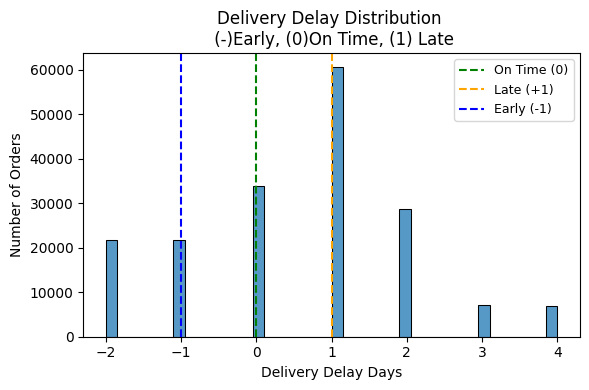

In [17]:
plt.figure(figsize=(6,4))
ax = sns.histplot(data=df,x="delivery_delay_days", bins=40)
plt.axvline(x=0,  color='green',  linestyle='--', linewidth=1.5, label='On Time (0)')
plt.axvline(x=1,  color='orange', linestyle='--', linewidth=1.5, label='Late (+1)')
plt.axvline(x=-1, color='blue',   linestyle='--', linewidth=1.5, label='Early (-1)')
plt.title("Delivery Delay Distribution \n (-)Early, (0)On Time, (1) Late")
plt.xlabel("Delivery Delay Days")
plt.ylabel("Number of Orders")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### Delivery Timing 

Most of the orders are delivered late(+1 day), showing that slight delays are common. Some deliveries arrive on time (0 days), while a few are delivered early (-1 or -2 days).

C:\Users\vishw\AppData\Local\Temp\ipykernel_5148\3325645683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Late_delivery_risk", data=df, palette="Set2")


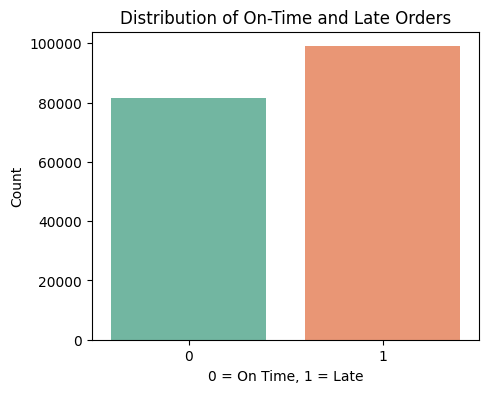

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x="Late_delivery_risk", data=df, palette="Set2")
plt.title("Distribution of On-Time and Late Orders")
plt.xlabel("0 = On Time, 1 = Late")
plt.ylabel("Count")
plt.show()

#### Distribution of On-Time and Late Orders Based on Late Delivery Risk
Most of the orders are being late (1), with a higher count compared to on-time deliveries (0).

C:\Users\vishw\AppData\Local\Temp\ipykernel_24804\2531442528.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=colors)
C:\Users\vishw\AppData\Local\Temp\ipykernel_24804\2531442528.py:4: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.barplot(x=counts.index, y=counts.values, palette=colors)


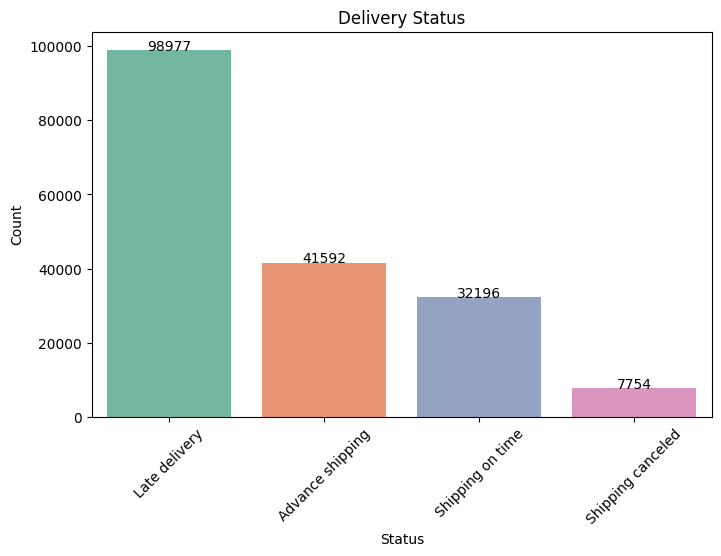

In [20]:
counts = df['Delivery Status'].value_counts()
colors = sns.color_palette("Set2")
plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, palette=colors)
plt.title('Delivery Status')
plt.xlabel('Status')
plt.ylabel('Count')
for i, j in enumerate(counts.values):
    plt.text(i, j, str(j), ha='center')
plt.xticks(rotation=45)
plt.show()

#### Distribution of Delivery Status Categories
Most deliveries are late (98,977), which is much higher than any other category.
Fewer orders are shipped in advance (41,592) or on time (32,196), and only a small number are cancelled (7,754).

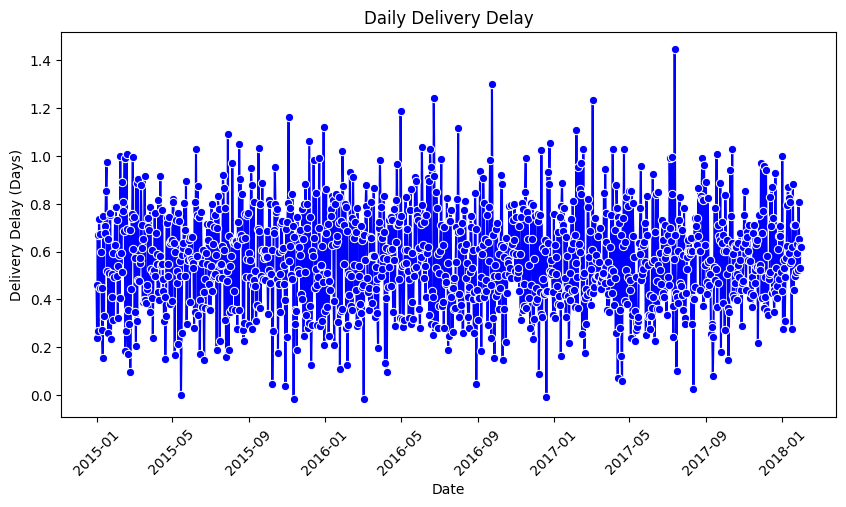

In [30]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
delay = df.groupby(df['order date (DateOrders)'].dt.date)['delivery_delay_days'].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(x=delay.index, y=delay.values, marker='o', color='blue')
plt.title('Daily Delivery Delay')
plt.xlabel('Date')
plt.ylabel('Delivery Delay (Days)')
plt.xticks(rotation=45)
plt.show()

#### Daily mean Delivery Delay line chart
I shows the daily delivery delays, mostly ranging between 0.4 and 0.8 days, from 2015 to 2018.

In [24]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(delay.dropna())
p_val = result[1]
output = {'p-value': round(p_val, 5),
    'Stationary':'Yes' if p_val < 0.05 else 'No'}
print(output)

{'p-value': 0.0, 'Stationary': 'Yes'}


According to Augmented Dickey Fuller Test, The p-value is less than 0.05, so the data is stationary.

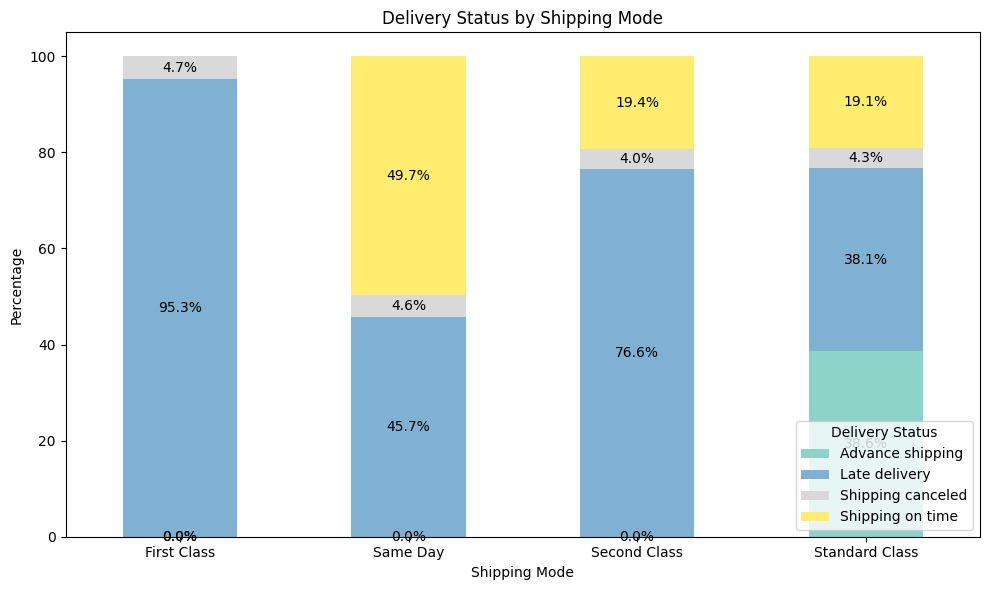

In [32]:
crosstable = pd.crosstab(df['Shipping Mode'], df['Delivery Status'], normalize='index')*100
ax = crosstable.plot(kind='bar', stacked=True, colormap='Set3', figsize=(10, 6), rot=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%',label_type='center')
plt.title('Delivery Status by Shipping Mode')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

#### Percentage Distribution of Delivery Status Across Shipping Modes

Late deliveries are highest in First Class (95.3%) and Second Class (76.6%), showing major delays in these modes.
Same Day and Standard Class perform better, with a more balanced mix of on-time and advance deliveries.

- In the dataset, most delays in First Class and Same Day shipping are only by 1 day. But these delivery types have very strict timing (0 or 1 day). So even a small delay of one day is marked as late. Because of this, they look like they perform worse than other shipping modes, even though the delay is very small.
- Example1: First Class delivery is expected in (1 day), but if it is delivered in (1-2 days), it is only 1 day late. Still, it is marked as a late delivery.
- Example2: Same Day delivery is expected in (0 days), but if it is delivered in (0-1 day), it is marked as late.

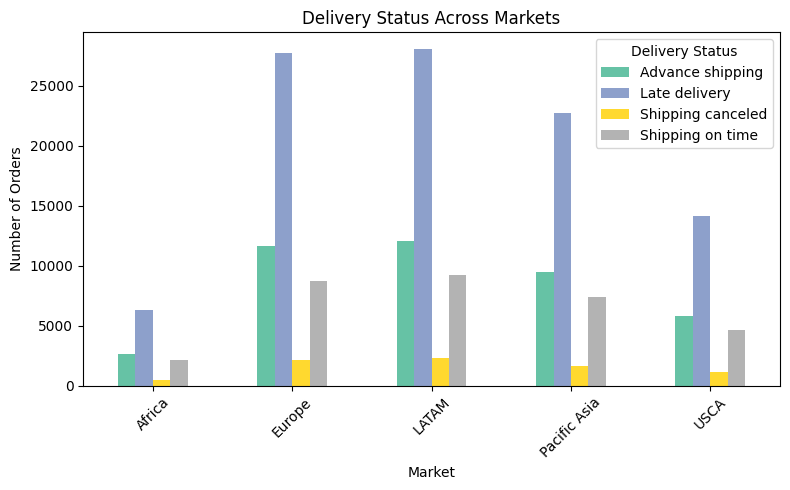

In [33]:
market_status = pd.crosstab(df['Market'], df['Delivery Status'])
ax = market_status.plot(kind='bar', figsize=(8, 5), colormap='Set2', rot=45)
plt.title('Delivery Status Across Markets')
plt.xlabel('Market')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Distribution of Delivery Status Across Different Markets

This shows how deliveries are performing in different markets, comparing early, on-time, late, and canceled orders. It is clear that late deliveries are the highest in every market, especially in Europe and LATAM.

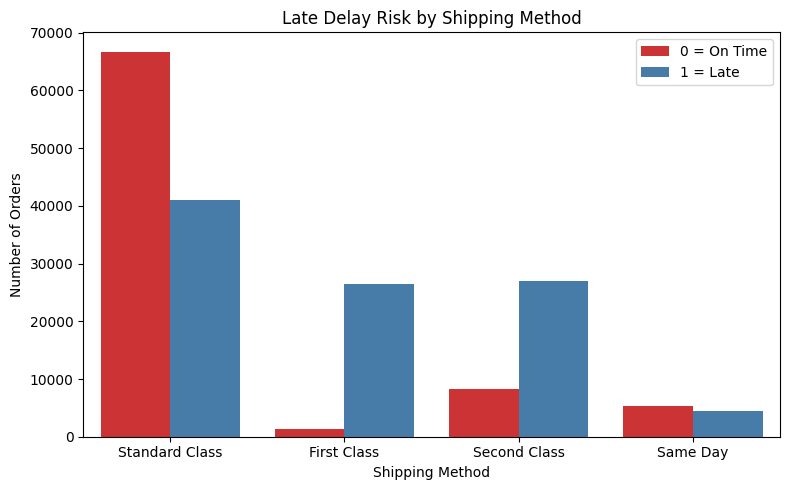

In [23]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='Shipping Mode', hue='Late_delivery_risk', palette='Set1')
plt.title('Late Delay Risk by Shipping Method')
plt.xlabel('Shipping Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['0 = On Time', '1 = Late'])
plt.tight_layout()
plt.show()

#### Late Delivery Risk Across Different Shipping Modes

This chart shows how many orders are on time (0) and late (1) in each shipping method.

C:\Users\vishw\AppData\Local\Temp\ipykernel_5148\1303815164.py:4: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.scatter_geo(


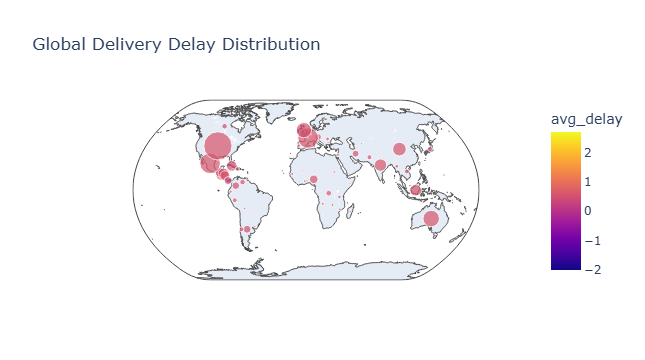

In [21]:
country_analysis = df.groupby('Order Country').agg(
    avg_delay=('delivery_delay_days', 'mean'), 
    order_count=('Order Country', 'count')).reset_index()
fig = px.scatter_geo(
    country_analysis,
    locations='Order Country',
    locationmode='country names',
    size='order_count',
    color='avg_delay',
    hover_name='Order Country',
    projection='natural earth',
    title='Global Delivery Delay Distribution')
fig.show()

#### Delivery Delay Across Countries

Countries with redder and bigger bubbles have longer delivery delays, while purple and smaller bubbles have faster deliveries.

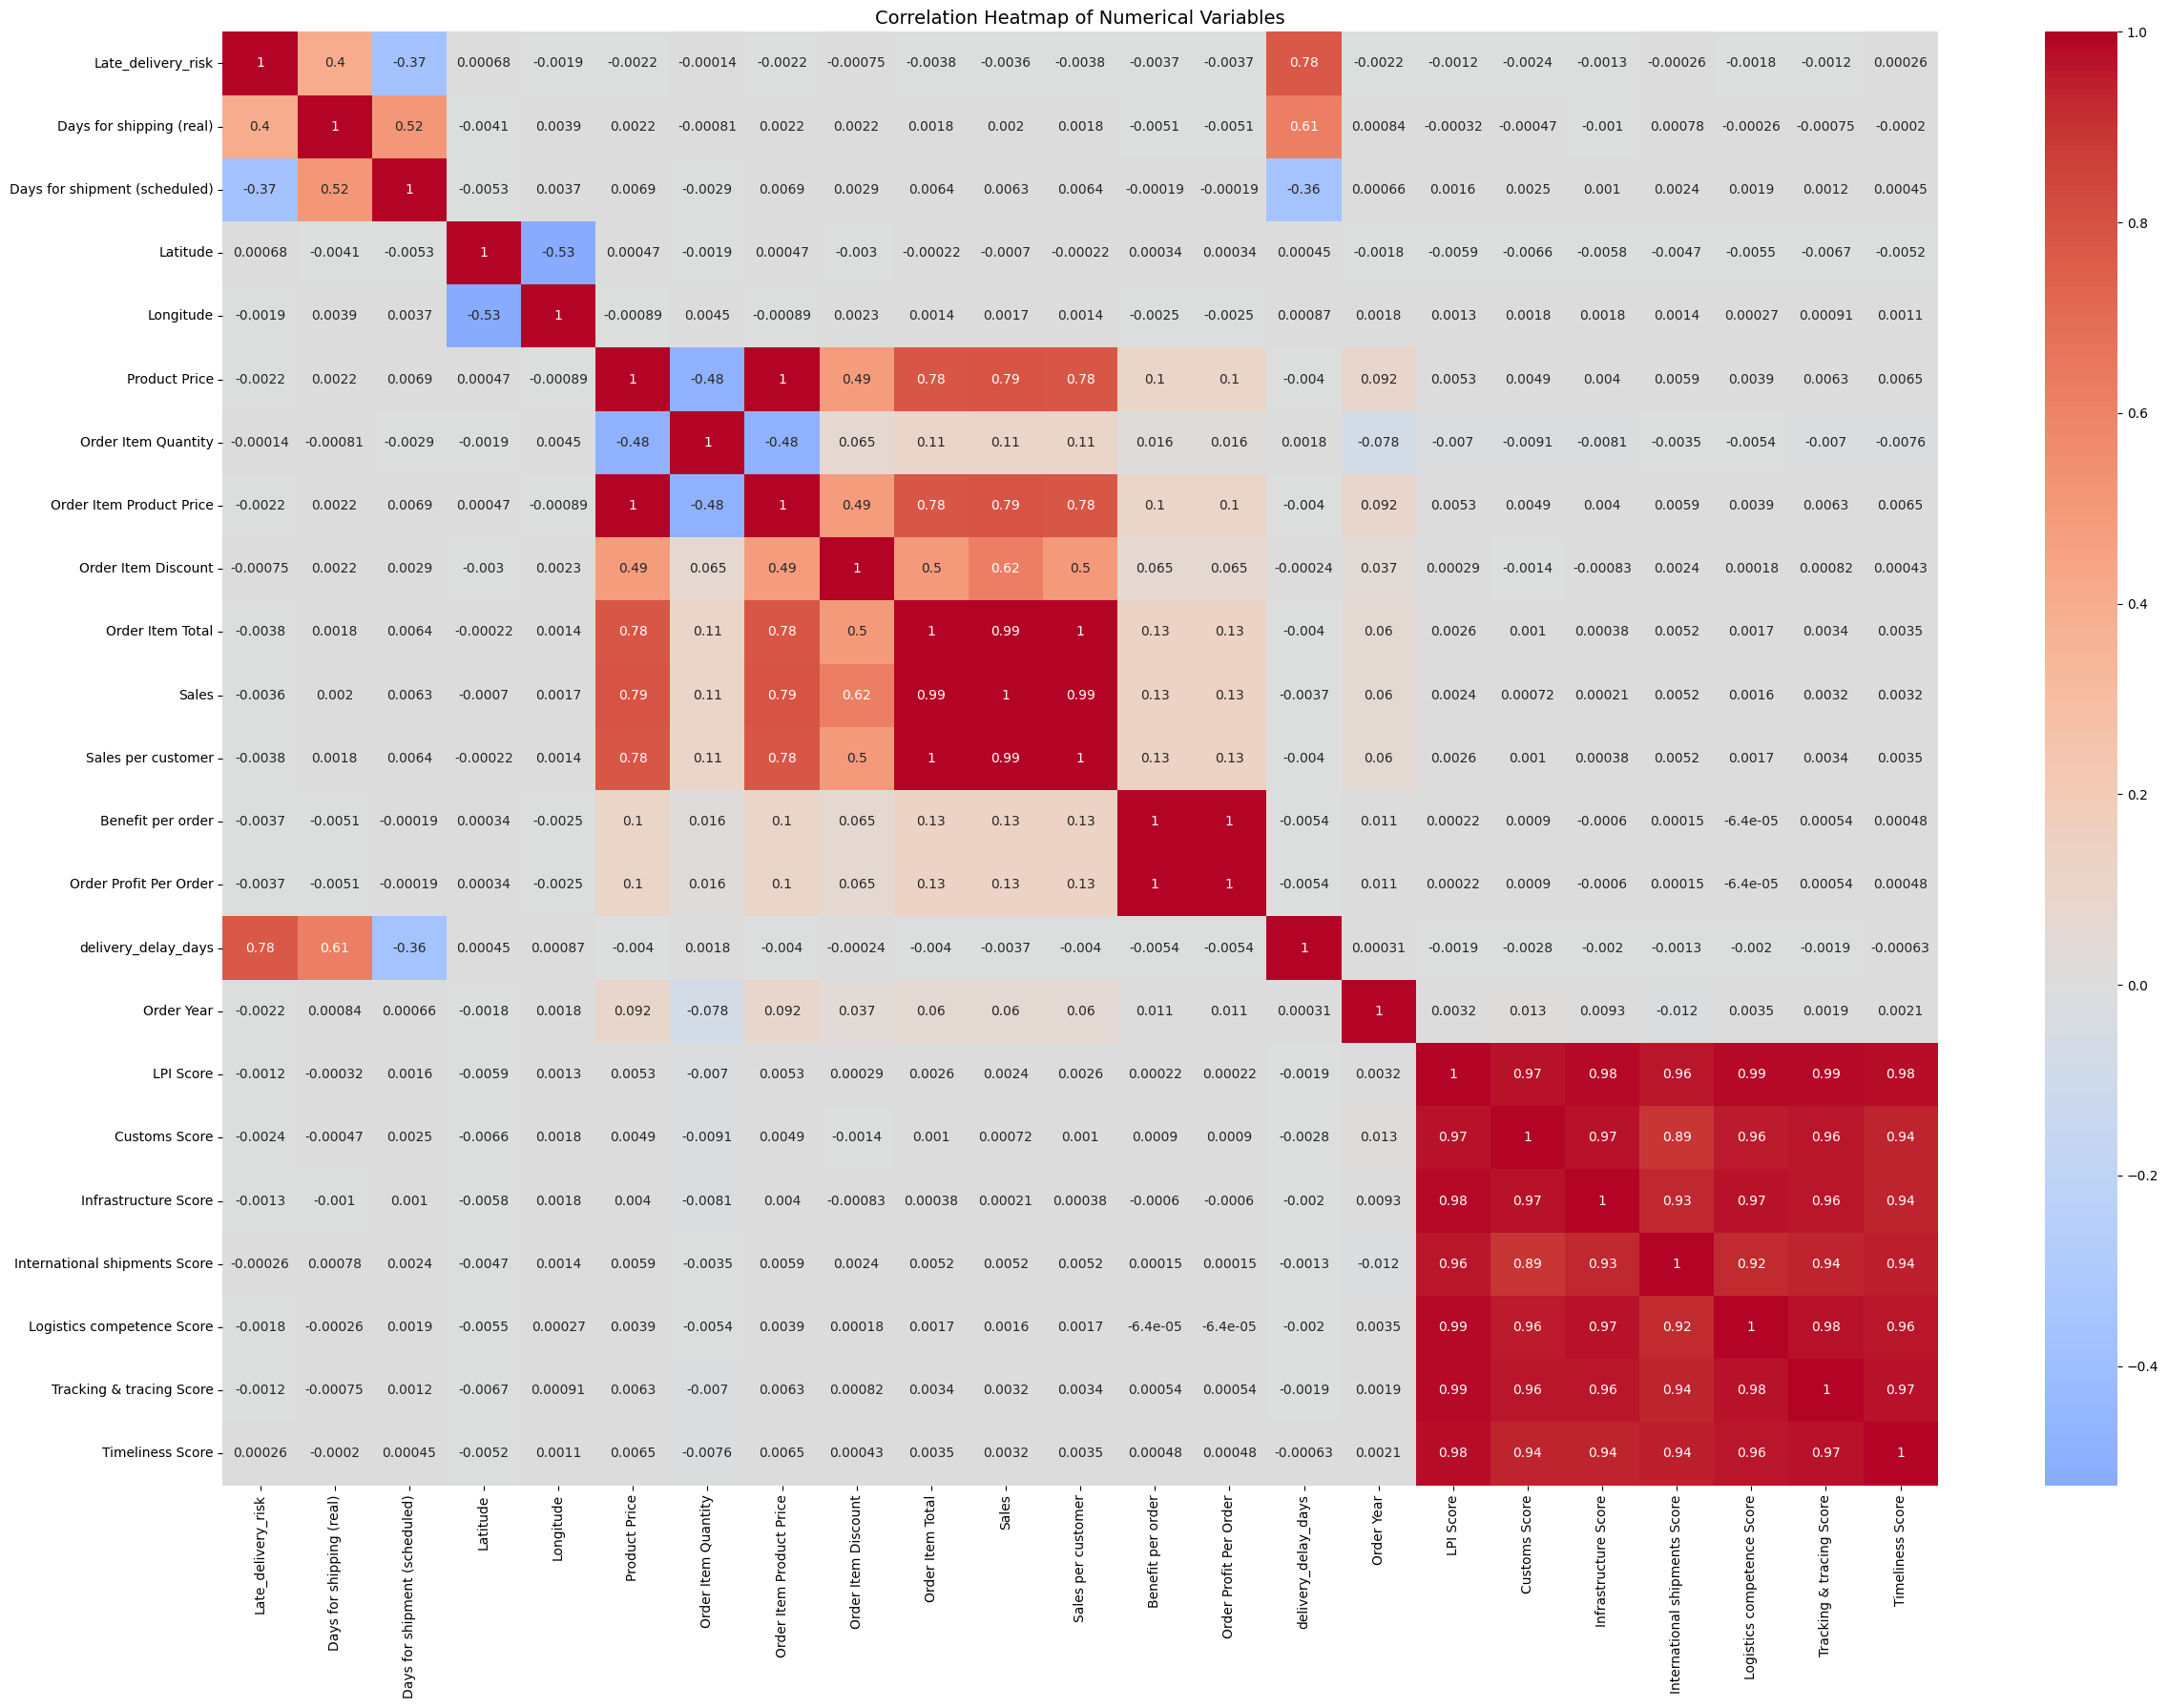

In [21]:
corr_matrix = num.corr()
plt.figure(figsize=(25, 18))
sns.heatmap(corr_matrix,cmap='coolwarm',center=0,annot=True)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=14)
plt.tight_layout()
plt.show()

#### Correlation Between Variables

This heatmap shows how different variables are related to each other, where red indicates strong positive relationships and blue indicates negative ones. It reveals that delivery delay is strongly linked with late delivery risk, while logistics-related scores (like LPI, infrastructure, and tracking) are highly correlated with each other.

In [22]:
from scipy.stats import ttest_ind, chi2_contingency

#### Statistical Analysis

In [15]:
results = []
late = df[df['Late_delivery_risk'] == 1]['LPI Score']
ontime = df[df['Late_delivery_risk'] == 0]['LPI Score']
t_stat, p_val = ttest_ind(late, ontime)
results.append(
    {'KPI': 'LPI Score',
    'Test': 'Independent t-test',
    'Statistic': round(t_stat, 3),
    'p-value': round(p_val, 5),
    'Significant': 'Yes' if p_val < 0.05 else 'No'})

late = df[df['Late_delivery_risk'] == 1]['Infrastructure Score']
ontime = df[df['Late_delivery_risk'] == 0]['Infrastructure Score']
t_stat, p_val = ttest_ind(late, ontime)
results.append(
    {'KPI': 'Infrastructure Score',
    'Test': 'Independent t-test',
    'Statistic': round(t_stat, 3),
    'p-value': round(p_val, 5),
    'Significant': 'Yes' if p_val < 0.05 else 'No'})

table = pd.crosstab(
    df['Shipping Mode'],df['Late_delivery_risk'])
chi2, p_val, _, _ = chi2_contingency(table)
results.append(
    {'KPI': 'Shipping Mode',
    'Test': 'Chi-square test',
    'Statistic': round(chi2, 3),
    'p-value': round(p_val, 5),
    'Significant': 'Yes' if p_val < 0.05 else 'No'})

kpi_results = pd.DataFrame(results)
kpi_results

,KPI,Test,Statistic,p-value,Significant
0,LPI Score,Independent t-test,-0.504,0.61415,No
1,Infrastructure Score,Independent t-test,-0.567,0.57083,No
2,Shipping Mode,Chi-square test,37716.043,0.00000,Yes


- LPI Score: Independent t-test showed no significant difference between late and on-time deliveries (p = 0.614). This means LPI score does not have a meaningful impact on delivery delays.
- Infrastructure Score: Independent t-test found no significant difference (p = 0.571). This means that infrastructure quality does not affect delivery delays.
- Shipping Mode: Chi-square test showed a statistically significant relationship (p = 0.000). This means the shipping method plays an important role in delivery delays.

### ML

Imported all packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, classification_report,
    confusion_matrix)
import shap

C:\Users\vishw\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv('Merged_Dataset.csv')

In [3]:
df['Late_delivery_risk']

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 180519, dtype: int64

In [4]:
target = 'Late_delivery_risk'
features = ['Days for shipment (scheduled)', 'Order_Year',
    'Shipping Mode', 'Order Item Quantity', 'LPI Score',
    'Customs Score', 'Infrastructure Score', 'International shipments Score',
    'Logistics competence Score', 'Tracking & tracing Score', 'Timeliness Score']
features = [c for c in features if c in df.columns]
X = df[features]
y = df[target]

##### Selected target variables and important features

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (144415, 10)
Testing set size: (36104, 10)


Split the data into 80 for train 20 for test.

stratify = y, it keep the data balanced by the same proportion of late and on-time deliveries

In [6]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Converts all categorical columns into numeric (0/1) format using one-hot encoding so the model can understand them.

In [7]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print('SMOTE:', X_train.shape)

SMOTE: (158362, 12)


SMOTE balances training data by increasing the number of minority class samples. It creates new data points instead of just copying existing ones, so the model learns better.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scale the data using Standard scaler

In [9]:
def evaluate_model(name, y_test, y_pred, y_prob, train_time, cv_mean=None):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_prob)
    return {'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc_score, 4),
        'CV Mean AUC': round(cv_mean, 4) if cv_mean else 'N/A',
        'Train Time (s)': round(train_time, 2)}

This function calculates different performance metrics like Accuracy, Precision, Recall, F1-score, ROC-AUC, and training time.

In [10]:
def run_cv(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits)
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    print(f' CV Folds : {np.round(scores, 4)}')
    print(f' Mean AUC : {scores.mean():.4f}')
    return scores.mean()

This function splits the data into multiple parts (folds) using Stratified K-Fold and checks the models performance on each part using ROC-AUC.

In [11]:
def print_results(name, y_test, y_pred, y_prob):
    print(f' {name}')
    print(f' Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f' ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))

This function prints key evaluation results such as Accuracy, ROC-AUC, confusion matrix, and classification report.

#### MODEL 1 — LOGISTIC REGRESSION

In [12]:
t0 = time.time()
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - t0

In [13]:
lr_cv = run_cv(lr_model, X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
print_results('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
lr_coef = pd.DataFrame({'Feature': X_train.columns,'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)
print(lr_coef)
lr_metrics = evaluate_model(
    'Logistic Regression', y_test, y_pred_lr, y_prob_lr, lr_time, lr_cv)

 CV Folds : [0.7275 0.7267 0.7327 0.7264 0.7318]
 Mean AUC : 0.7290
 Logistic Regression
 Accuracy : 0.6967
 ROC-AUC  : 0.7294
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

Confusion Matrix:
[[14415  1893]
 [ 9056 10740]]
                          Feature  Coefficient
8                Timeliness Score     0.075629
6      Logistics competence Score     0.019678
5   International shipments Score     0.012092
1             Order Item Quantity    -0.003899
2                       LPI Score    -0.004240
3                   Customs Score    -0.009496
4            Infrastructure Score    -0.033545
7        Tracking & tracing Score    -0.062395
10     Shipping Mode_Second Class    -0.477016
11  

Logistic Regression model: Evaluates its performance using cross-validation and test metrics, and extracts feature coefficients to identify the variables that influence the predictions.

#### MODEL 2 — DECISION TREE

In [14]:
param_grid_dt = {'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
    param_grid_dt,cv=5,
    scoring='roc_auc',
    n_jobs=-1)
t0 = time.time()
grid_dt.fit(X_train, y_train)
dt_model = grid_dt.best_estimator_
dt_time = time.time() - t0

In [15]:
print(f"Best parameters: {grid_dt.best_params_}")
dt_cv = run_cv(dt_model, X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
print_results('Decision Tree', y_test, y_pred_dt, y_prob_dt)
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(dt_importance)
dt_metrics = evaluate_model(
    'Decision Tree', y_test, y_pred_dt, y_prob_dt, dt_time, dt_cv)

Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
 CV Folds : [0.7298 0.7275 0.7315 0.7282 0.7311]
 Mean AUC : 0.7296
 Decision Tree
 Accuracy : 0.6968
 ROC-AUC  : 0.7319
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

Confusion Matrix:
[[14412  1896]
 [ 9049 10747]]
                          Feature  Importance
11   Shipping Mode_Standard Class    0.726726
9          Shipping Mode_Same Day    0.151817
10     Shipping Mode_Second Class    0.115941
8                Timeliness Score    0.001852
2                       LPI Score    0.001429
7        Tracking & tracing Score    0.000667
6      Logistics competence Score    0.000468
4            Infrastructure Sc

Decision Tree model using GridSearchCV to find the best parameters, trains and evaluates it using cross-validation and test metrics, and then identifies the most important features that influencing the predictions.

#### MODEL 3 — NAIVE BAYES (Gaussian)


In [16]:
t0 = time.time()
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_time = time.time() - t0

In [17]:
nb_cv = run_cv(nb_model, X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]
print_results('Naive Bayes', y_test, y_pred_nb, y_prob_nb)

nb_metrics = evaluate_model(
    'Naive Bayes', y_test, y_pred_nb, y_prob_nb, nb_time, nb_cv)

 CV Folds : [0.7031 0.7009 0.7076 0.7059 0.7047]
 Mean AUC : 0.7044
 Naive Bayes
 Accuracy : 0.6919
 ROC-AUC  : 0.7063
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.82      0.71     16308
           1       0.80      0.59      0.68     19796

    accuracy                           0.69     36104
   macro avg       0.71      0.70      0.69     36104
weighted avg       0.72      0.69      0.69     36104

Confusion Matrix:
[[13340  2968]
 [ 8156 11640]]


Naive Bayes model, measures how long it takes to train, evaluates its performance using cross-validation and test metrics.

#### MODEL 4 — RANDOM FOREST


In [18]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),param_grid_rf,cv=5,
    scoring='roc_auc',n_jobs=-1)
t0 = time.time()
grid_rf.fit(X_train, y_train)
rf_model = grid_rf.best_estimator_
rf_time = time.time() - t0

In [19]:
print(f'Best parameters: {grid_rf.best_params_}')
rf_cv = run_cv(rf_model, X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
print_results('Random Forest', y_test, y_pred_rf, y_prob_rf)
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(rf_importance)
rf_metrics = evaluate_model(
    'Random Forest', y_test, y_pred_rf, y_prob_rf, rf_time, rf_cv)

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
 CV Folds : [0.7304 0.7271 0.7335 0.7288 0.7315]
 Mean AUC : 0.7302
 Random Forest
 Accuracy : 0.6968
 ROC-AUC  : 0.7316
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

Confusion Matrix:
[[14412  1896]
 [ 9049 10747]]
                          Feature  Importance
0   Days for shipment (scheduled)    0.448610
11   Shipping Mode_Standard Class    0.349832
10     Shipping Mode_Second Class    0.125733
9          Shipping Mode_Same Day    0.067342
7        Tracking & tracing Score    0.001448
8                Timeliness Score    0.001192
4            Infrastructure Score    0.001185
5   International shipments Score

SHAP plot for Random Forest


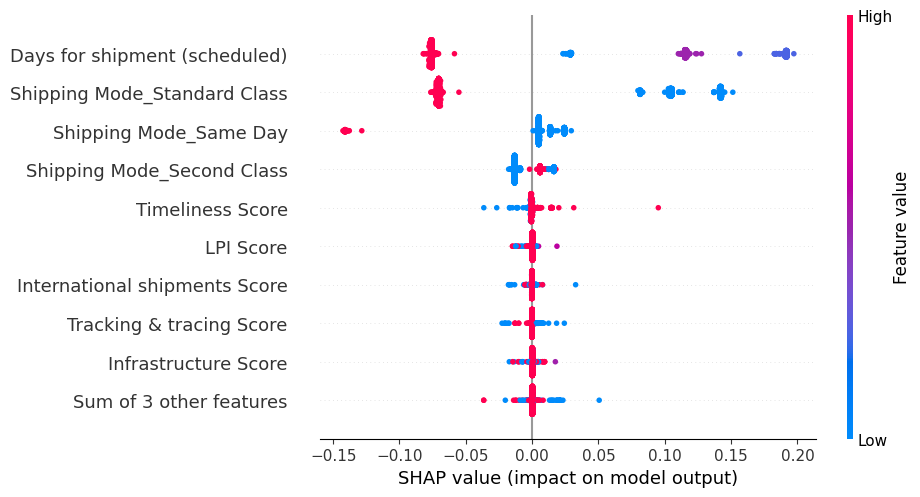

In [20]:
print('SHAP plot for Random Forest')
explainer   = shap.TreeExplainer(rf_model)
sample_shap = X_train.sample(2000, random_state=42)
shap_vals   = explainer(sample_shap)
shap_class1 = shap_vals[:, :, 1]
shap.plots.beeswarm(shap_class1)

Random Forest model using GridSearchCV, evaluates it with cross-validation and test metrics, explains feature impact using a SHAP beeswarm plot, and extracts the most important features to compare model performance.

#### MODEL 5 — XGBOOST


In [21]:
param_grid_xgb = {'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]}
grid_xgb = GridSearchCV(XGBClassifier(colsample_bytree=0.8,random_state=42,
            eval_metric='logloss',use_label_encoder=False),
            param_grid_xgb,cv=5,scoring='roc_auc',n_jobs=-1)
t0 = time.time()
grid_xgb.fit(X_train, y_train)
xgb_model = grid_xgb.best_estimator_
xgb_time = time.time() - t0

C:\Users\vishw\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:53:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [22]:
print(f'Best parameters: {grid_xgb.best_params_}')
print('Cross-Validation:')
xgb_cv = run_cv(xgb_model, X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print_results('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print('Top 10 Feature Importances:')
print(xgb_importance)
xgb_metrics = evaluate_model(
    'XGBoost', y_test, y_pred_xgb, y_prob_xgb, xgb_time, xgb_cv)

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Cross-Validation:
 CV Folds : [0.7301 0.7262 0.7325 0.7288 0.7318]
 Mean AUC : 0.7299
 XGBoost
 Accuracy : 0.6971
 ROC-AUC  : 0.7320
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

Confusion Matrix:
[[14399  1909]
 [ 9026 10770]]
Top 10 Feature Importances:
                          Feature  Importance
11   Shipping Mode_Standard Class    0.473840
0   Days for shipment (scheduled)    0.371573
9          Shipping Mode_Same Day    0.110015
10     Shipping Mode_Second Class    0.034947
5   International shipments Score    0.001435
8                Timeliness Score    0.001393
7        Tracking & tr

XGBoost model using GridSearchCV, evaluates it with cross-validation and test performance metrics, and then identifies the most important features influencing predictions.


#### MODEL 6 — LIGHTGBM


In [24]:
param_grid_lgbm = {'n_estimators': [100, 200],
    'max_depth': [5, 10, -1],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50],
    'subsample': [0.8, 1.0]}
grid_lgbm = GridSearchCV(LGBMClassifier(objective='binary',
        random_state=42,n_jobs=-1,verbosity=-1),
    param_grid_lgbm,cv=5,
    scoring='roc_auc',n_jobs=-1)

In [25]:
t0 = time.time()
grid_lgbm.fit(X_train, y_train)
lgbm_model = grid_lgbm.best_estimator_
lgbm_time = time.time() - t0
print(f'Best parameters: {grid_lgbm.best_params_}')
lgbm_cv = run_cv(lgbm_model, X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print_results('LightGBM', y_test, y_pred_lgbm, y_prob_lgbm)
lgbm_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(lgbm_importance)

lgbm_metrics = evaluate_model(
    'LightGBM', y_test, y_pred_lgbm, y_prob_lgbm, lgbm_time, lgbm_cv)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
 CV Folds : [0.729  0.7261 0.7329 0.7288 0.7316]
 Mean AUC : 0.7297
 LightGBM
 Accuracy : 0.6971
 ROC-AUC  : 0.7325
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

Confusion Matrix:
[[14398  1910]
 [ 9025 10771]]
                          Feature  Importance
1             Order Item Quantity         652
2                       LPI Score         352
0   Days for shipment (scheduled)         266
3                   Customs Score         229
8                Timeliness Score         206
5   International shipments Score         155
6      Logistics competence Score         147
4   

LightGBM model using GridSearchCV, evaluates it with cross-validation and test performance metrics, and then identifies the most important features influencing predictions.

#### MODEL 7 — STACKING CLASSIFIER


In [35]:
stack_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))])
stack_rf = RandomForestClassifier(
    n_estimators=200,max_depth=5,min_samples_split=2,
    random_state=42,n_jobs=-1)
stack_lgbm = LGBMClassifier(
    n_estimators=200,max_depth=4,learning_rate=0.1,
    subsample=0.8,colsample_bytree=0.8,random_state=42)
stack_model = StackingClassifier(
    estimators=[
        ('lr', stack_lr),
        ('rf', stack_rf),
        ('lgbm', stack_lgbm)],
   final_estimator=XGBClassifier(n_estimators=100, max_depth=3,
        learning_rate=0.1,subsample=0.8, colsample_bytree=0.8,
        random_state=42,eval_metric='logloss'),
    cv=5,n_jobs=-1,passthrough=False)

In [36]:
t0 = time.time()
stack_model.fit(X_train, y_train)
stack_time = time.time() - t0
stack_cv = run_cv(stack_model, X_train, y_train)

y_pred_stack = stack_model.predict(X_test)
y_prob_stack = stack_model.predict_proba(X_test)[:, 1]
print_results('Stacking Classifier', y_test, y_pred_stack, y_prob_stack)
stack_metrics = evaluate_model(
    'Stacking Classifier',y_test,y_pred_stack,y_prob_stack,
    stack_time,stack_cv)

 CV Folds : [0.7283 0.727  0.7306 0.7276 0.7319]
 Mean AUC : 0.7291
 Stacking Classifier
 Accuracy : 0.6969
 ROC-AUC  : 0.7333
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

Confusion Matrix:
[[14410  1898]
 [ 9046 10750]]


The Stacking Classifier combines multiple base models and uses XGBoost as the final estimator, then evaluates the model using cross-validation and test performance metrics.

In [37]:
print('Comparative model performance summary')
results_df = pd.DataFrame([
    lr_metrics,
    dt_metrics,
    nb_metrics,
    rf_metrics,
    xgb_metrics,
    lgbm_metrics,
    stack_metrics])
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
print(results_df.to_string(index=False))

Comparative model performance summary
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Mean AUC  Train Time (s)
Logistic Regression    0.6967     0.8502  0.5425    0.6624   0.7294       0.7290          0.2400
      Decision Tree    0.6968     0.8500  0.5429    0.6626   0.7319       0.7296          8.5800
        Naive Bayes    0.6919     0.7968  0.5880    0.6767   0.7063       0.7044          0.0800
      Random Forest    0.6968     0.8500  0.5429    0.6626   0.7316       0.7302        137.1500
            XGBoost    0.6971     0.8494  0.5440    0.6633   0.7320       0.7299         32.0900
           LightGBM    0.6971     0.8494  0.5441    0.6633   0.7325       0.7297        173.7600
Stacking Classifier    0.6969     0.8499  0.5430    0.6627   0.7333       0.7291         34.1400


Compared all trained models and identified the best-performing model for each evaluation metric. **LightGBM** achieved the highest ROC-AUC, while XGBoost and LightGBM showed the best Accuracy.

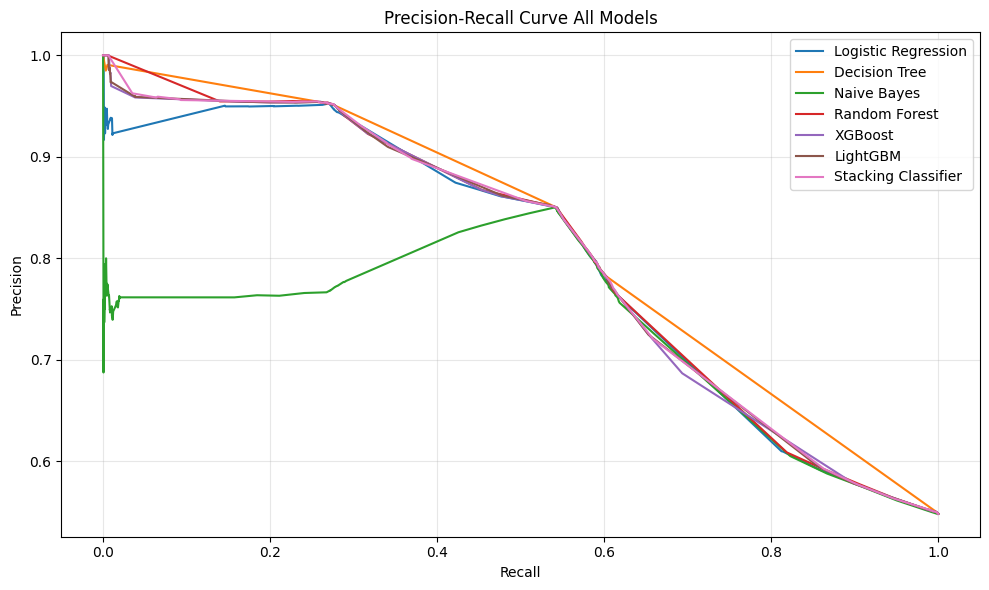

In [38]:
plt.figure(figsize=(10, 6))
pr_models = [
    ('Logistic Regression', y_prob_lr),
    ('Decision Tree', y_prob_dt),
    ('Naive Bayes', y_prob_nb),
    ('Random Forest', y_prob_rf),
    ('XGBoost', y_prob_xgb),
    ('LightGBM', y_prob_lgbm),
    ('Stacking Classifier', y_prob_stack)]
for name, probs in pr_models:
    prec_c, rec_c, _ = precision_recall_curve(y_test, probs)
    plt.plot(rec_c, prec_c, label=name)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve All Models')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Precision-Recall Curve Comparison of Classification Models
The Precision-Recall curve compares five models, where a curve closer to  the top-right corner (highest precision and recall together) performs best with XGBoost and LightGBM

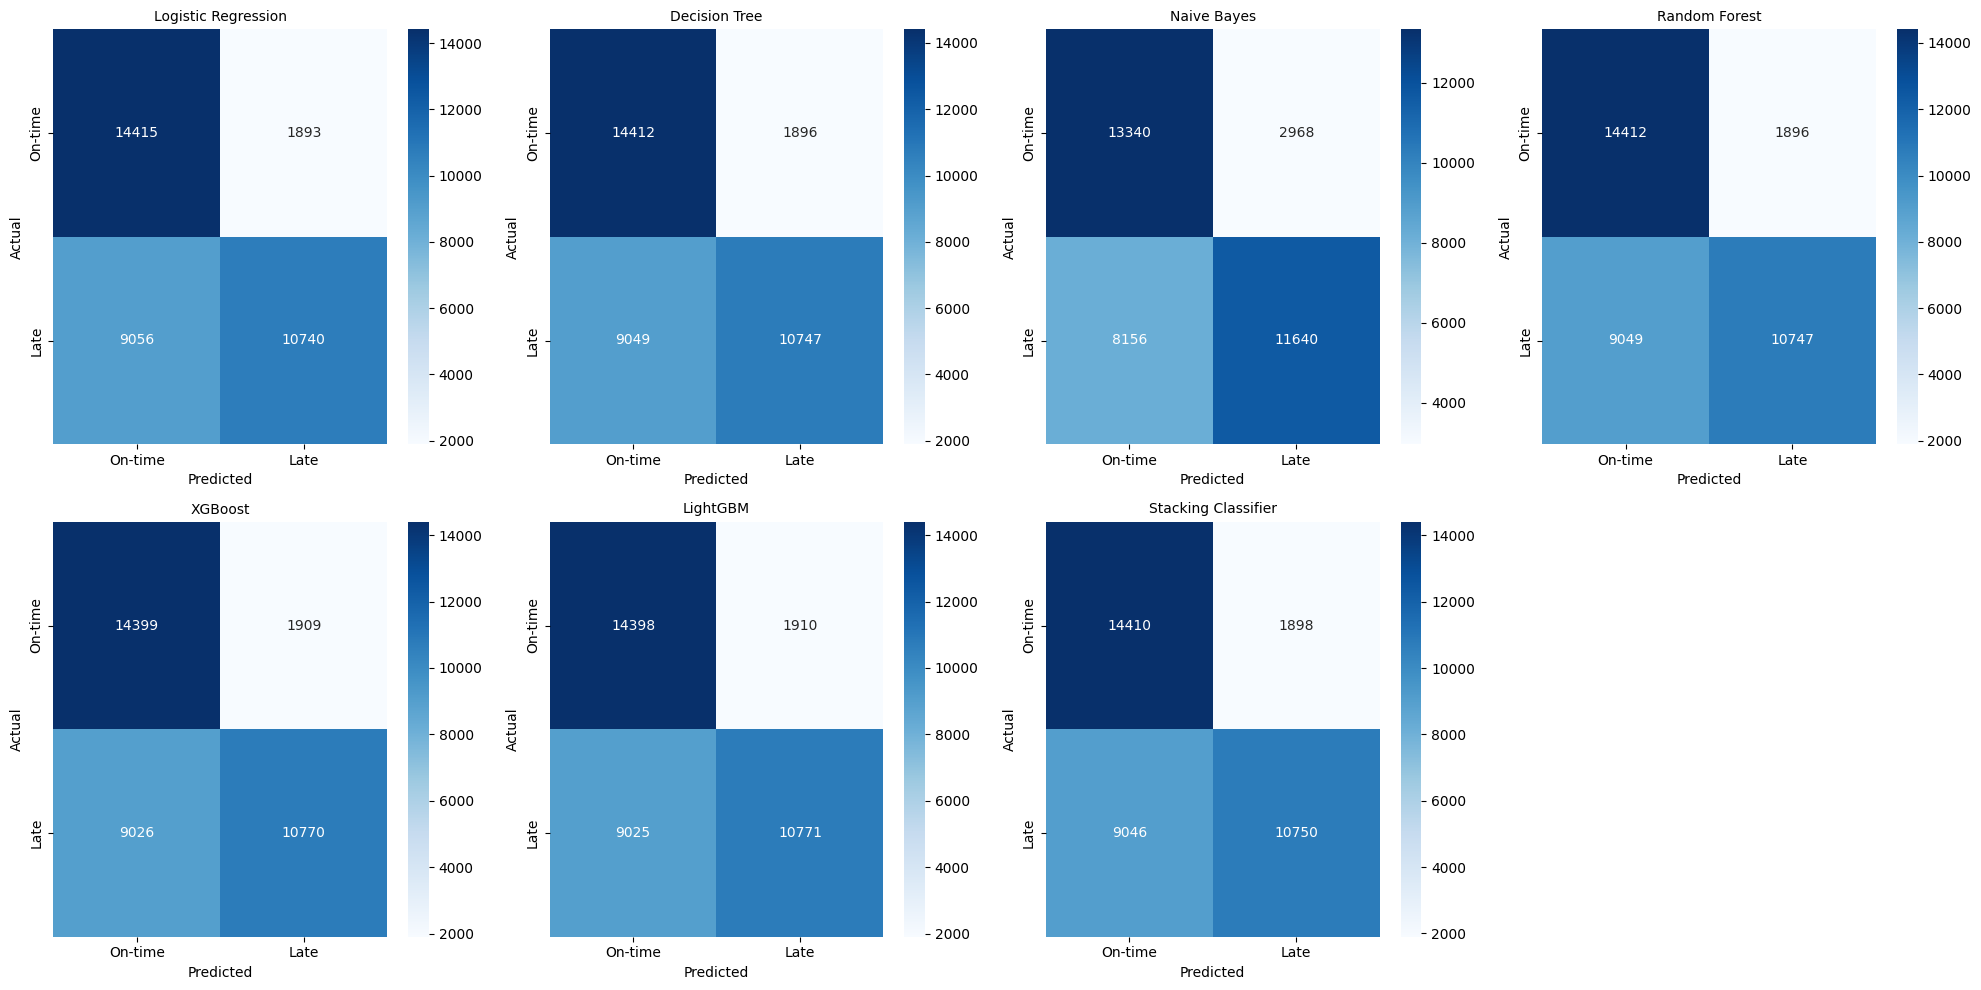

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  
model_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('Naive Bayes', y_pred_nb),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
    ('LightGBM', y_pred_lgbm),
    ('Stacking Classifier', y_pred_stack)]
for i, (name, preds) in enumerate(model_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
        xticklabels=['On-time', 'Late'],
        yticklabels=['On-time', 'Late'])
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

#### Confusion Matrix Comparison Across Classification Models
All models except Naive Bayes correctly identify about 14,400 on-time and 9,000 late flights.

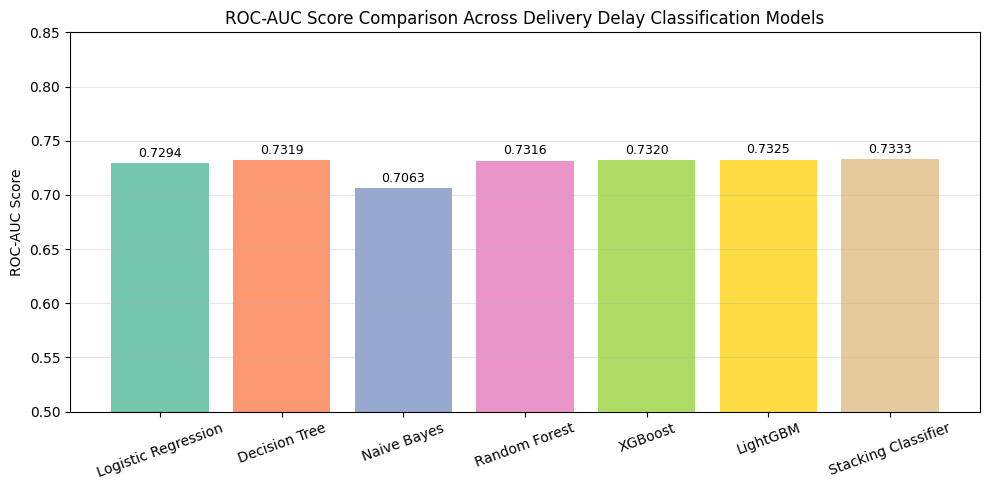

In [46]:
colors = sns.color_palette("Set2", len(results_df))
plt.figure(figsize=(10, 5))
bars = plt.bar(
    results_df['Model'],
    results_df['ROC-AUC'],
    color=colors,
    alpha=0.9)
for bar, val in zip(bars, results_df['ROC-AUC']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{val:.4f}',
        ha='center',
        va='bottom',
        fontsize=9)
plt.ylim(0.5, 0.85)
plt.title('ROC-AUC Score Comparison Across Delivery Delay Classification Models')
plt.ylabel('ROC-AUC Score')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### ROC-AUC Comparison of Classification Models for Late Delivery Prediction
The ROC-AUC bar chart makes it easy to see that most models score near 0.73, but Naive Bayes is lower at 0.706.

### Average delivery delay Forecast

In [48]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import StepLR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [68]:
df = pd.read_csv('Forecast.csv')
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)'], errors='coerce')
df.head()

,Unnamed: 0,order date (DateOrders),delivery_delay_days
0,33833,2015-01-01 00:00:00,-2
1,77011,2015-01-01 00:21:00,-1
2,109322,2015-01-01 00:21:00,-1
3,87884,2015-01-01 00:21:00,-1
4,114915,2015-01-01 01:03:00,1


In [69]:
df = df.groupby(
    df['order date (DateOrders)'].dt.date
)['delivery_delay_days'].mean().reset_index()
df.columns = ['Date', 'Delay']
df

,Date,Delay
0,2015-01-01,0.4583
1,2015-01-02,0.2403
2,2015-01-03,0.6704
3,2015-01-04,0.2670
4,2015-01-05,0.7375
...,...,...
1122,2018-01-27,0.8088
1123,2018-01-28,0.6522
1124,2018-01-29,0.5294
1125,2018-01-30,0.6232


It groups the data by each date and calculates the *average delivery delay* for each day.
- Example: On Jan 1, I had 3 orders
Delays = 0 days, 1 day, 0 days
- Average delay = (0 + 1 + 0) ÷ 3 = 0.33 days

In [70]:
print('Total days:', len(df))
print('Average Delay:', df['Delay'].mean())
print('Minimum Delay:', df['Delay'].min())
print('Maximum Delay:', df['Delay'].max())

Total days: 1127
Average Delay: 0.5672638769271837
Minimum Delay: -0.01764705882352941
Maximum Delay: 1.4437869822485208


In [71]:
delay_values = df['Delay'].values.reshape(-1,1)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_delay = scaler.fit_transform(delay_values)

Converts the delay values into a column format and scales them between 0 and 1.

In [72]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)
SEQ_LEN = 30
X, y = create_sequences(scaled_delay, SEQ_LEN)

This function  creates sequences of 30 days of delay data to use as input, and the next day’s delay as the output for prediction.

In [73]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f'Training samples:  {len(X_train)}')
print(f'Test samples:      {len(X_test)}')

Training samples:  877
Test samples:      220


Splits the data into 80% training and 20% testing.

In [74]:
noise_level = 0.01
X_train_aug = X_train + np.random.normal(0, noise_level, X_train.shape)
X_train_aug = np.clip(X_train_aug, 0.0, 1.0)
X_train = np.vstack((X_train, X_train_aug))
y_train = np.vstack((y_train, y_train))

In this code adds small random noise to the training data to create more data, then combines it with the original data to improve the model.

In [75]:
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float()
X_test_t  = torch.from_numpy(X_test).float()
y_test_t  = torch.from_numpy(y_test).float()

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

here converts the data into PyTorch tensors, creates a training dataset, and loads it in small batches (32 samples) for training the model.

In [82]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.2)
        self.linear = nn.Linear(128, 1)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:, -1, :])

LSTM (Long Short-Term Memory): The model looks at a sequence of past values (like previous days delays) and tries to find patterns. The model has two LSTM layers with 128 nuerons to understand the data better. Dropout (0.2) helps to avoid overfitting by 
ignoring some parts during training. 

It takes the last output and passes it to a simple layer that gives one final prediction (next days delay).

In [83]:
EPOCHS = 60
loss_function = nn.MSELoss()
def train_model(optimizer_name):
    model = LSTMModel()
    if optimizer_name == 'NAdam':
        optimizer = torch.optim.NAdam(model.parameters(), lr=0.001)
    elif optimizer_name == 'Adafactor':
        optimizer = torch.optim.Adafactor(model.parameters(), lr=0.01)
    elif optimizer_name == 'Adamax':
        optimizer = torch.optim.Adamax(model.parameters(), lr=0.002)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
    else:
        raise ValueError(f'Unknown optimizer: {optimizer_name}')
    scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
    losses = []
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for seq, labels in train_loader:
            optimizer.zero_grad()
            pred = model(seq)
            loss = loss_function(pred, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        losses.append(epoch_loss / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f" {optimizer_name} | Epoch {epoch+1:3d}/{EPOCHS} | Loss: {epoch_loss/len(train_loader):.6f}")
    return model, losses

Trains the LSTM model for 60 epochs using a chosen optimizer (NAdam, Adafactor, Adamax, and RMSprop). In each epoch, the model learns from the training data, calculates the error using MSE loss, and updates its weights to reduce the error. It also uses gradient clipping to keep training stable and a learning rate scheduler to slowly reduce the learning rate.

In [84]:
model_nadam, losses_nadam = train_model('NAdam')
model_adafactor, losses_adafactor = train_model('Adafactor')
model_adamax, losses_adamax = train_model('Adamax')
model_rmsprop, losses_rmsprop = train_model('RMSprop')

 NAdam | Epoch  10/60 | Loss: 0.022239
 NAdam | Epoch  20/60 | Loss: 0.021995
 NAdam | Epoch  30/60 | Loss: 0.021680
 NAdam | Epoch  40/60 | Loss: 0.021694
 NAdam | Epoch  50/60 | Loss: 0.021539
 NAdam | Epoch  60/60 | Loss: 0.021513
 Adafactor | Epoch  10/60 | Loss: 0.022373
 Adafactor | Epoch  20/60 | Loss: 0.022175
 Adafactor | Epoch  30/60 | Loss: 0.021733
 Adafactor | Epoch  40/60 | Loss: 0.021776
 Adafactor | Epoch  50/60 | Loss: 0.021559
 Adafactor | Epoch  60/60 | Loss: 0.021464
 Adamax | Epoch  10/60 | Loss: 0.022091
 Adamax | Epoch  20/60 | Loss: 0.021891
 Adamax | Epoch  30/60 | Loss: 0.021629
 Adamax | Epoch  40/60 | Loss: 0.021738
 Adamax | Epoch  50/60 | Loss: 0.021637
 Adamax | Epoch  60/60 | Loss: 0.021585
 RMSprop | Epoch  10/60 | Loss: 0.022327
 RMSprop | Epoch  20/60 | Loss: 0.022072
 RMSprop | Epoch  30/60 | Loss: 0.021776
 RMSprop | Epoch  40/60 | Loss: 0.021451
 RMSprop | Epoch  50/60 | Loss: 0.021095
 RMSprop | Epoch  60/60 | Loss: 0.020889


In [85]:
def evaluate_model(model):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).detach().numpy()
    actual = scaler.inverse_transform(y_test_t.numpy().reshape(-1, 1))
    predicted = scaler.inverse_transform(preds.reshape(-1, 1))
    actual_safe = np.where(np.abs(actual) < 1e-8, 1e-8, actual)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual_safe)) * 100
    r2   = r2_score(actual, predicted)
    return actual, predicted, rmse, mae, mape, r2
actual_delay, pred_nadam,     rmse_n,  mae_n,  mape_n,  r2_n  = evaluate_model(model_nadam)
_,            pred_adafactor, rmse_af, mae_af, mape_af, r2_af = evaluate_model(model_adafactor)
_,            pred_adamax,    rmse_ax, mae_ax, mape_ax, r2_ax = evaluate_model(model_adamax)
_,            pred_rms,       rmse_r,  mae_r,  mape_r,  r2_r  = evaluate_model(model_rmsprop)

Evaluates the trained models by comparing their predictions with the real values from the test data. First, it sets the model to evaluation mode and makes predictions without training. Then it converts both predicted and actual values back to the original scale. After that, it calculates performance metrics like RMSE, MAE, MAPE, and R² to measure how accurate each model is. Finally, it evaluates all four models (NAdam, Adafactor, Adamax, and RMSprop) and stores their results.

In [86]:
metrics_df = pd.DataFrame({
    'Optimizer': ['NAdam', 'Adafactor', 'Adamax', 'RMSprop'],
    'RMSE': [rmse_n, rmse_af, rmse_ax, rmse_r],
    'MAE': [mae_n, mae_af, mae_ax, mae_r],
    'MAPE (%)': [mape_n, mape_af, mape_ax, mape_r],
    'R²': [r2_n, r2_af, r2_ax, r2_r],
})
print(metrics_df.to_string(index=False))

best_idx = metrics_df['RMSE'].idxmin()
best_name = metrics_df.loc[best_idx, 'Optimizer']
print(f"\nBest optimizer (lowest RMSE): {best_name}")

Optimizer   RMSE    MAE  MAPE (%)      R²
    NAdam 0.1995 0.1532   44.1481 -0.0102
Adafactor 0.2015 0.1527   44.0811 -0.0309
   Adamax 0.1997 0.1529   43.7751 -0.0122
  RMSprop 0.2066 0.1583   42.8515 -0.0840

Best optimizer (lowest RMSE): NAdam


Compare the performance of four models (NAdam, Adafactor, Adamax, and RMSprop).

It stores their evaluation results (RMSE, MAE, MAPE, and R2) in a DataFrame.

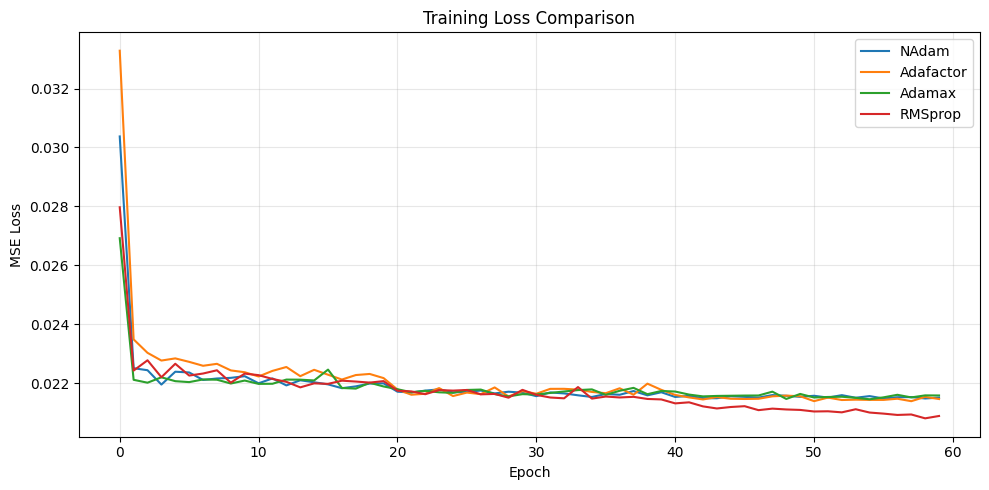

In [88]:
plt.figure(figsize=(10, 5))
plt.plot(losses_nadam, label='NAdam')
plt.plot(losses_adafactor, label='Adafactor')
plt.plot(losses_adamax, label='Adamax')
plt.plot(losses_rmsprop, label='RMSprop')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Training Loss Comparison of LSTM Optimizers
This graph is to compare how the training loss changes over time for four optimizers.

It shows how the error (MSE loss) decreases over each epoch for all models using different colors.

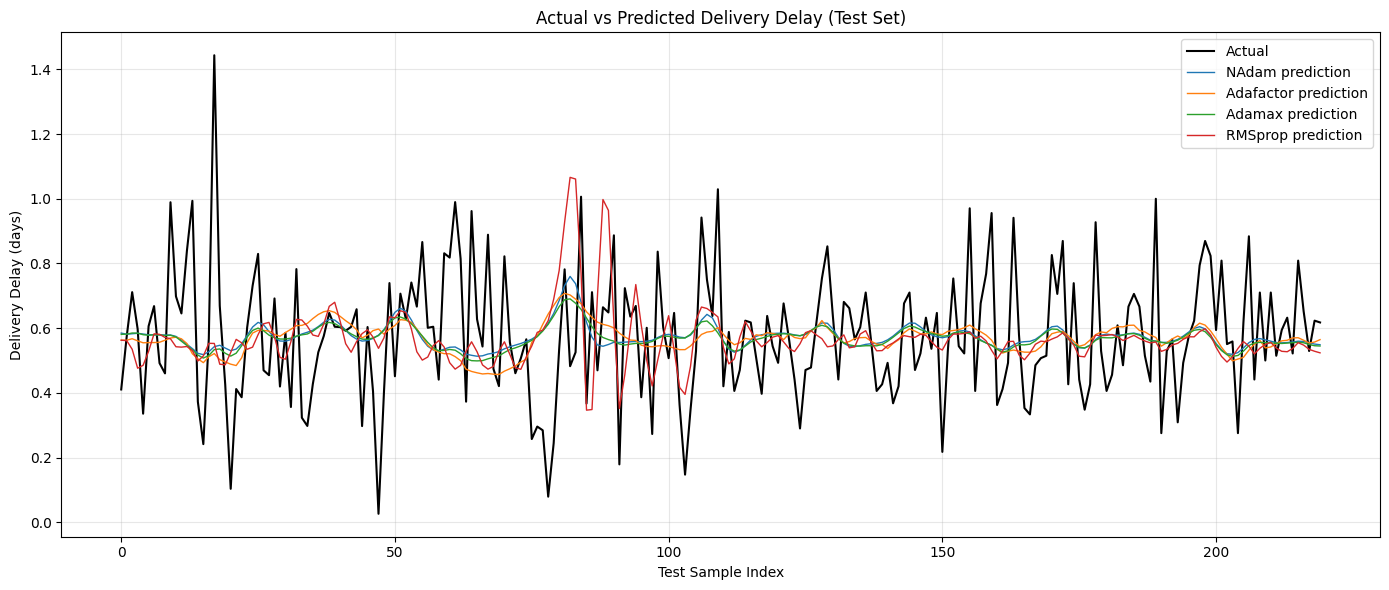

In [91]:
plt.figure(figsize=(14, 6))
plt.plot(actual_delay, label='Actual', color='black', linewidth=1.5)
plt.plot(pred_nadam, label='NAdam prediction', linewidth=1)
plt.plot(pred_adafactor, label='Adafactor prediction', linewidth=1)
plt.plot(pred_adamax, label='Adamax prediction', linewidth=1)
plt.plot(pred_rms, label='RMSprop prediction', linewidth=1)
plt.title('Actual vs Predicted Delivery Delay (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Delivery Delay (days)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Comparison of Actual and Predicted Delivery Delay in the Test Set
Comparing the real delivery delays with the predicted delays. The black line shows the actual values, while the colored lines show predictions from each model.

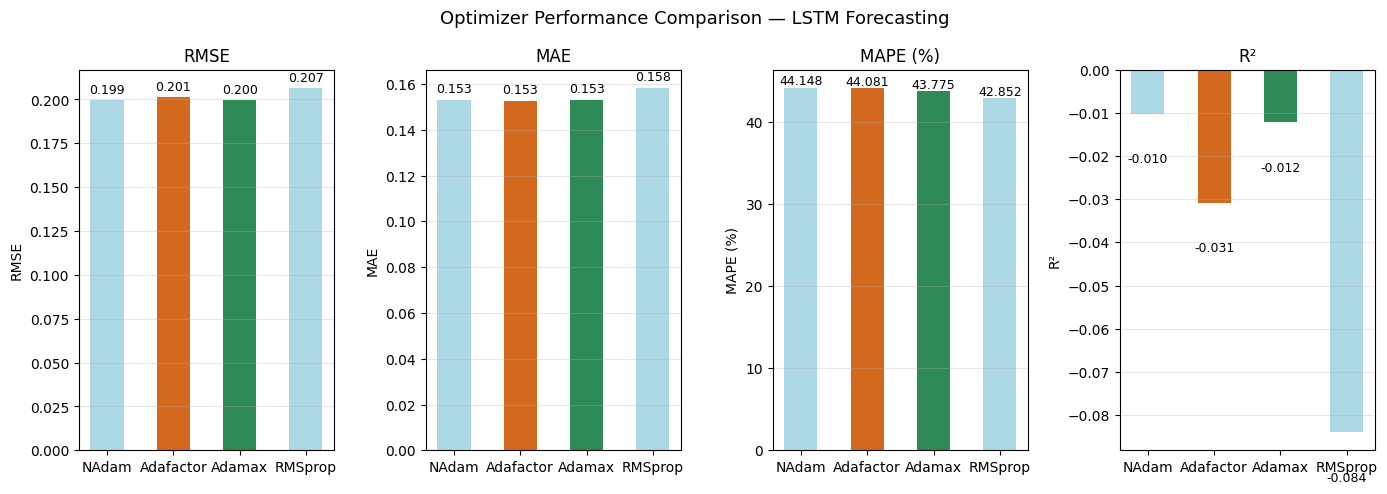

In [92]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
metrics_to_plot = ['RMSE', 'MAE', 'MAPE (%)', 'R²']
colors = ['lightblue', 'chocolate', 'seagreen']
for ax, metric in zip(axes, metrics_to_plot):
    vals = metrics_df[metric].values
    bars = ax.bar(metrics_df['Optimizer'], vals, color=colors, width=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        label_y = bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.012
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_y,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=9)
plt.suptitle('Optimizer Performance Comparison — LSTM Forecasting', fontsize=13)
plt.tight_layout()
plt.show()

#### Performance Comparison of Optimizers for LSTM Delivery Delay Forecasting
Compare the performance of four optimizers. Each subplot shows one metric (RMSE, MAE, MAPE, and R2). The bars represent how each optimizer performs for that metric, and the exact values are written on top of each bar.


In [94]:
FUTURE_DAYS = 15
last_sequence = scaled_delay[-SEQ_LEN:].copy()
current_seq = last_sequence.copy()
future_preds = []
best_model = model_nadam
best_model.eval()
with torch.no_grad():
    for _ in range(FUTURE_DAYS):
        seq_tensor = torch.from_numpy(
            current_seq.reshape(1, SEQ_LEN, 1)
        ).float()
        next_pred = best_model(seq_tensor).detach().numpy()[0][0]
        future_preds.append(next_pred)
        current_seq = np.append(current_seq[1:], [[next_pred]], axis=0)
future_forecast = scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)
)
last_date = pd.to_datetime(df['Date'].iloc[-1])
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=FUTURE_DAYS
)
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast Delay': future_forecast.flatten()
})
print('15-DAY FORECAST')
print(forecast_df.to_string())


15-DAY FORECAST
         Date  Forecast Delay
0  2018-02-01          0.5491
1  2018-02-02          0.5516
2  2018-02-03          0.5556
3  2018-02-04          0.5605
4  2018-02-05          0.5652
5  2018-02-06          0.5689
6  2018-02-07          0.5713
7  2018-02-08          0.5722
8  2018-02-09          0.5721
9  2018-02-10          0.5715
10 2018-02-11          0.5708
11 2018-02-12          0.5703
12 2018-02-13          0.5701
13 2018-02-14          0.5701
14 2018-02-15          0.5702


Predicts the **next 15 days of delivery delay** using the trained LSTM model.

It starts with last 30 days of data and uses the best model (NAdam) to predict the next day. After each prediction, it adds the new value into the sequence and removes the oldest one, so it can keep predicting step by step for 15 days. Then it converts the predictions back to the original scale and creates future dates for each prediction.

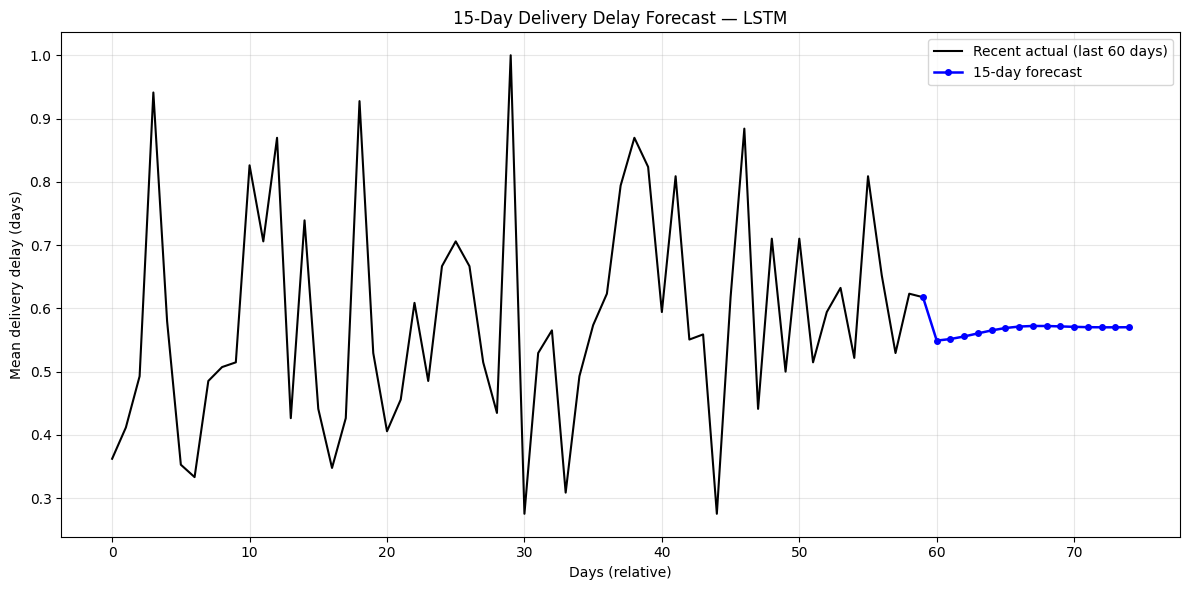

In [95]:
plt.figure(figsize=(12, 6))
recent_actual = df['Delay'].tail(60).values
plt.plot(range(len(recent_actual)), recent_actual,
         label='Recent actual (last 60 days)', color='black', linewidth=1.5)
bridge = np.concatenate([[recent_actual[-1]], future_forecast.flatten()])
plt.plot(range(len(recent_actual) - 1, len(recent_actual) - 1 + FUTURE_DAYS + 1),
         bridge,
         label='15-day forecast', color='Blue',
         marker='o', markersize=4, linewidth=1.8)
plt.title('15-Day Delivery Delay Forecast — LSTM')
plt.xlabel('Days (relative)')
plt.ylabel('Mean delivery delay (days)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### LSTM-Based Forecast of Average Delivery Delay for the Next 15 Days
The delivery delays forecast: The last 60 days of actual delays and connects it with the next 15 days of predicted delays. The black line shows real past data, and the blue line shows the forecast made by the LSTM model.